<a href="https://colab.research.google.com/github/srkatsaras/FRTN65---Code-and-Notebooks/blob/main/lab_song_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [2]:
# Download data
!wget -O training_data.csv http://handsonml.control.lth.se/data/training_data.csv
!wget -O songs_to_classify.csv http://handsonml.control.lth.se/data/songs_to_classify.csv

--2026-09-26 12:27:01--  http://handsonml.control.lth.se/data/training_data.csv
Resolving handsonml.control.lth.se (handsonml.control.lth.se)... 130.235.83.36, 2001:6b0:16:248:2406:1311:4200:0
Connecting to handsonml.control.lth.se (handsonml.control.lth.se)|130.235.83.36|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 54950 (54K) [text/csv]
Saving to: ‘training_data.csv’

training_data.csv   100%[===================>]  53.66K  --.-KB/s    in 0.06s   

2026-09-26 12:27:01 (975 KB/s) - ‘training_data.csv’ saved [54950/54950]

--2026-09-26 12:27:01--  http://handsonml.control.lth.se/data/songs_to_classify.csv
Resolving handsonml.control.lth.se (handsonml.control.lth.se)... 130.235.83.36, 2001:6b0:16:248:2406:1311:4200:0
Connecting to handsonml.control.lth.se (handsonml.control.lth.se)|130.235.83.36|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14306 (14K) [text/csv]
Saving to: ‘songs_to_classify.csv’

songs_to_classify.c 100%[==========

In [8]:
# Load data
train = pd.read_csv("training_data.csv")
test = pd.read_csv("songs_to_classify.csv")

dataset = pd.concat([train, test])
train.shape, test.shape

((750, 14), (200, 13))

In [16]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   acousticness         750 non-null    float64 
 1   danceability         750 non-null    float64 
 2   duration             750 non-null    int64   
 3   energy               750 non-null    float64 
 4   instrumentalness     750 non-null    float64 
 5   key                  750 non-null    int64   
 6   liveness             750 non-null    float64 
 7   loudness             750 non-null    float64 
 8   mode                 750 non-null    int64   
 9   speechiness          750 non-null    float64 
 10  tempo                750 non-null    float64 
 11  time_signature       750 non-null    int64   
 12  valence              750 non-null    float64 
 13  label                750 non-null    int64   
 14  acousticnessBin      750 non-null    category
 15  danceabilityBin      75

In [17]:
train.describe()

,acousticness,danceability,duration,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,label
count,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000
mean,0.357394,0.596439,220112.733333,0.594188,0.100245,4.829333,0.203376,-8.509339,0.741333,0.098966,120.405761,3.902667,0.497321,0.602667
std,0.338405,0.172036,65587.690483,0.253301,0.259921,3.636001,0.177609,5.039488,0.438194,0.104715,28.378116,0.400091,0.239615,0.489673
min,0.000001,0.107000,33840.000000,0.009250,0.000000,0.000000,0.024000,-29.601000,0.000000,0.023400,55.747000,1.000000,0.033200,0.000000
25%,0.037150,0.480000,185490.250000,0.423250,0.000000,1.000000,0.094550,-10.173500,0.000000,0.035900,98.998000,4.000000,0.297000,0.000000
50%,0.244500,0.606000,215108.500000,0.631500,0.000010,5.000000,0.129000,-7.270000,1.000000,0.048750,120.104500,4.000000,0.483000,1.000000
75%,0.678500,0.715750,244236.750000,0.804750,0.002245,8.000000,0.264750,-5.097750,1.000000,0.113000,138.074750,4.000000,0.684500,1.000000
max,0.994000,0.986000,675360.000000,0.995000,0.967000,11.000000,0.979000,-0.533000,1.000000,0.721000,204.162000,5.000000,0.975000,1.000000


In [39]:
print("Total Dataset Unique Values:\n", dataset.nunique())
print("\nTrain Dataset Unique Values:\n", train.nunique())

Total Dataset Unique Values:
 acousticness        734
danceability        500
duration            904
energy              583
instrumentalness    522
key                  12
liveness            507
loudness            890
mode                  2
speechiness         530
tempo               917
time_signature        4
valence             567
label                 2
dtype: int64

Train Dataset Unique Values:
 acousticness           596
danceability           458
duration               717
energy                 502
instrumentalness       431
key                     12
liveness               445
loudness               710
mode                     2
speechiness            457
tempo                  729
time_signature           4
valence                487
label                    2
acousticnessBin         10
danceabilityBin         10
energyBin               10
instrumentalnessBin     10
livenessBin             10
loudnessBin             10
speechinessBin           9
tempoBin               

In [37]:
train['time_signature'].unique()

array([4, 3, 5, 1])

In [13]:
# Inspect data
train.head()

,acousticness,danceability,duration,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,label
0,0.713,0.514,100125,0.521,0.816000,8,0.1120,-14.835,0,0.0444,119.879,4,0.143,1
1,0.192,0.714,207019,0.614,0.000000,4,0.2630,-6.935,1,0.0319,123.969,4,0.582,1
2,0.333,0.630,216200,0.455,0.000004,5,0.1270,-9.290,1,0.0292,139.931,4,0.199,1
3,0.601,0.810,136413,0.221,0.210000,5,0.1840,-11.005,1,0.0429,109.960,4,0.798,1
4,0.883,0.465,181440,0.459,0.000173,6,0.0692,-8.137,0,0.0351,90.807,4,0.288,1


In [38]:
train['acousticnessBin'] = pd.cut(train['acousticness'], 10)
train['danceabilityBin'] = pd.cut(train['danceability'], 10)
train['energyBin'] = pd.cut(train['energy'], 10)
train['instrumentalnessBin'] = pd.cut(train['instrumentalness'], 10)
train['livenessBin'] = pd.cut(train['liveness'], 10)
train['loudnessBin'] = pd.cut(train['loudness'], 10)
train['speechinessBin'] = pd.cut(train['speechiness'], 10)
train['tempoBin'] = pd.cut(train['tempo'], 10)
train['valenceBin'] = pd.cut(train['valence'], 10)
train['durationBin'] = pd.cut(train['duration'], 10)

<Axes: ylabel='tempo'>

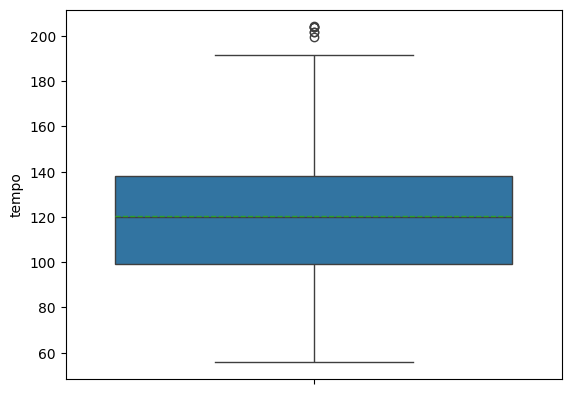

In [44]:
sns.boxplot(data=train['tempo'], showmeans=True, meanline=True)

/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)


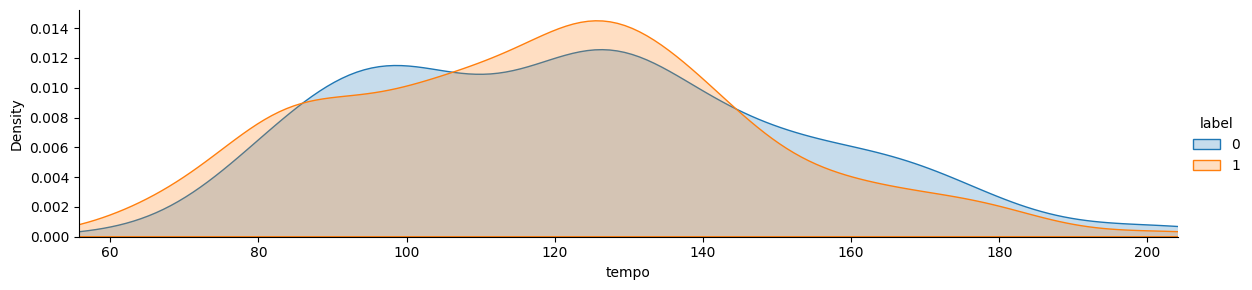

In [49]:
a = sns.FacetGrid( train, hue = 'label', aspect=4 )
a.map(sns.kdeplot, 'tempo', shade= True )

a.set(xlim=(train['tempo'].min(), train['tempo'].max()))
a.add_legend()

In [ ]:
# select which features to use
features = ['danceability','key','loudness','instrumentalness','liveness']
X_train = train.loc[:,features]
y_train = train.loc[:,'label']
X_test = test.loc[:,features]


In [ ]:
X_train

,danceability,key,loudness,instrumentalness,liveness
0,0.514,8,-14.835,0.816000,0.1120
1,0.714,4,-6.935,0.000000,0.2630
2,0.630,5,-9.290,0.000004,0.1270
3,0.810,5,-11.005,0.210000,0.1840
4,0.465,6,-8.137,0.000173,0.0692
...,...,...,...,...,...
745,0.374,6,-4.108,0.000156,0.1250
746,0.487,10,-3.293,0.006020,0.0968
747,0.605,0,-7.631,0.000000,0.3590
748,0.700,3,-6.892,0.000028,0.1220


In [ ]:
# Normalize data. Can also be done using sklearn methods such as
# MinMaxScaler() or StandardScaler()
X_trainn = X_train*1/np.max(np.abs(X_train), axis=0)
X_testn = X_test*1/np.max(np.abs(X_train), axis=0)

In [ ]:
# note: all inputs/features are treated as quantitative/numeric
# some of the features are perhaps more sensible to treat as
# qualitative/cathegorical. For that sklearn preprocessing methods
# such as OneHotEncoder() can be used

# define the k-NN model. To set n_neighbors in a systematic way, use cross validation!
knnmodel = KNeighborsClassifier(n_neighbors=5)

# feed it with data and train it
knnmodel.fit(X_trainn, y_train)

# make predictions
predictions = knnmodel.predict(X=X_testn)
print(predictions)

[0 1 0 1 0 0 0 1 0 0 1 0 0 1 1 1 1 0 1 1 0 0 1 0 0 1 1 0 0 1 1 1 1 1 0 1 1
 1 0 1 0 1 0 1 1 1 0 1 1 0 1 0 1 0 0 1 1 1 0 0 1 1 0 0 1 1 1 0 1 1 1 0 1 1
 1 1 0 1 1 0 1 1 0 0 1 0 1 1 1 1 1 0 0 0 1 0 1 1 1 1 0 0 1 0 0 1 0 0 0 1 1
 1 0 1 1 0 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 0 1 1 1 0 0
 1 0 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 1 1
 1 1 0 0 0 1 0 0 0 1 1 1 1 1 1]
